# Sesión 6 — Análisis pushover monotónico incremental

## Caso `mi_primer_analisis`

Se aplica gravedad, se calibra $EI$ y $M$–$\theta_p(P_g)$, se incorporan criterios externos y se ejecuta el empuje lateral con control directo del desplazamiento promedio del techo. El resultado principal es la curva de capacidad $V_b$–$u_{control}$.

## 1. Equilibrio incremental y variable de control

En cada paso se satisfacen simultáneamente el equilibrio $\mathbf P_g+\lambda\mathbf P-\mathbf f_{int}(\mathbf u)=\mathbf0$ y la restricción $\mathbf c^T\mathbf u=u_{objetivo}$. Las incógnitas son los desplazamientos libres y el factor lateral $\lambda$.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

def buscar_raiz(inicio=None):
    inicio = Path.cwd() if inicio is None else Path(inicio)
    for carpeta in (inicio, *inicio.parents):
        if (carpeta / "temario.md").is_file() and (carpeta / "PUSHOVER_PORTABLE").is_dir():
            return carpeta
    raise FileNotFoundError(
        "No se encontró la raíz del curso. En Colab, clona o monta primero el repositorio."
    )

RAIZ = buscar_raiz()
PORTABLE = RAIZ / "PUSHOVER_PORTABLE"
if str(PORTABLE) in sys.path:
    sys.path.remove(str(PORTABLE))
sys.path.insert(0, str(PORTABLE))

RUTA_MAESTRA = PORTABLE / "casos" / "mi_primer_analisis" / "entrada_maestra.json"
RUTA_GEOMETRIA = PORTABLE / "casos" / "mi_primer_analisis" / "geometria_secciones.json"
CASO_ID = "mi_primer_analisis"

from ejecutar_pushover import cargar_entrada_maestra, evaluar_calidad_curva, ejecutar_cadena
from sesion_03.biblioteca_rotulas import leer_contrato_sesion03
from sesion_05.contrato_portable import guardar_contrato_sesion05
from sesion_06.caso_medrano import crear_caso_gravitacional_desde_datos, resumen_cargas
from sesion_06.pushover import (
    ConfiguracionPushover, analizar_pushover, crear_patron_lateral, guardar_resultados,
)
from sesion_06.rotulas_axiales import calibrar_contrato_nivel1
from sesion_06.criterios_externos import aplicar_criterios_externos
from sesion_06.visualizacion import guardar_figuras

entrada, _, cargas = cargar_entrada_maestra(RUTA_MAESTRA)
RUTA_C03 = RAIZ / "sesion_03" / "resultados_mi_primer_analisis" / "contrato_sesion03.json"
RUTA_C05 = RAIZ / "sesion_05" / "resultados_mi_primer_analisis" / "contrato_sesion05.json"
biblioteca = leer_contrato_sesion03(RUTA_C03)["biblioteca_rotulas"]
contrato_s5 = json.loads(RUTA_C05.read_text(encoding="utf-8"))
print("Contrato S5:", RUTA_C05.relative_to(RAIZ), "| schema", contrato_s5["schema_version"])

Contrato S5: sesion_05\resultados_mi_primer_analisis\contrato_sesion05.json | schema 3.4


## 2. Estado gravitacional y calibración axial

La combinación es $1.0D+0.25L$. La carga axial obtenida en cada columna selecciona por interpolación su rigidez y su ley de rótula. El proceso se repite hasta que la variación axial cumpla la tolerancia configurada.

In [2]:
caso_gravedad = crear_caso_gravitacional_desde_datos(contrato_s5, cargas, entrada)
cfg = ConfiguracionPushover(**entrada["pushover"].get("configuracion", {}))
asignacion = {int(k): str(v) for k, v in contrato_s5["asignacion_secciones"].items()}
ccfg = entrada["calibracion"]
calibracion = calibrar_contrato_nivel1(
    contrato_s5, caso_gravedad, asignacion, biblioteca,
    configuracion=cfg, fuera_de_rango=ccfg["fuera_de_rango"],
    actualizar_EI=ccfg["actualizar_EI"],
    tolerancia_axial_fraccion=ccfg["tolerancia_axial_fraccion"],
    max_iteraciones=ccfg["max_iteraciones"],
    catalogo_secciones=entrada["secciones"],
)
assert calibracion["convergio"]
contrato_cal = calibracion["contrato"]
resumen_g = resumen_cargas(contrato_cal, caso_gravedad)
print("Calibración convergió en", len(calibracion["historia_calibracion"]), "iteraciones")
print(f"Carga gravitacional total: {resumen_g['carga_gravitacional_total_kgf']/1000:.3f} tf")

Calibración convergió en 2 iteraciones
Carga gravitacional total: 17.570 tf


## 3. Criterios de aceptación y patrón lateral

Los límites IO–LS–CP se leen de un catálogo externo provisional. Como existe un solo piso, los patrones triangular y uniforme producen el mismo vector normalizado: toda la carga lateral se aplica al nivel superior y se reparte entre sus nodos.

In [3]:
crit = entrada["configuracion_criterios"]
contrato_cal = aplicar_criterios_externos(
    contrato_cal, entrada["_catalogo_criterios"],
    permitir_provisionales=crit["permitir_provisionales"],
    politica_exceso_capacidad=crit["politica_exceso_capacidad"],
)
n_pisos = int(contrato_cal["geometria"]["n_pisos"])
coef = np.arange(1, n_pisos + 1, dtype=float)
patron = crear_patron_lateral(contrato_cal, coef)
print("Coeficientes por piso:", coef)
print("Suma del patrón horizontal:", patron[0::3].sum())
assert n_pisos == 1 and np.isclose(patron[0::3].sum(), 1.0)

Coeficientes por piso: [1.]
Suma del patrón horizontal: 1.0


## 4. Ejecución y curva de capacidad

El desplazamiento promedio del techo aumenta en 0.25 cm por paso hasta alcanzar un criterio de parada. Cada punto conserva cortante basal, deriva, iteraciones, residuo y eventos de rótula.

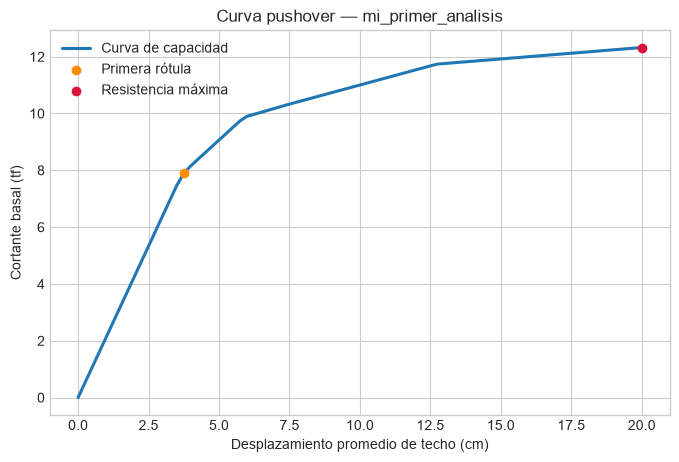

Convergió: True | parada: desplazamiento_maximo
Puntos: 81 | rótulas formadas: 10 | calidad: True
Final: u=20.00 cm, Vb=12.322 tf


In [4]:
resultados = analizar_pushover(
    contrato_cal, patron, cargas_gravitacionales=caso_gravedad, configuracion=cfg
)
calidad = evaluar_calidad_curva(resultados, entrada["pushover"].get("calidad_curva", {}))
resultados["calidad_curva"] = calidad
hist = resultados["historia"]
u = np.array([h["desplazamiento_control_cm"] for h in hist])
V = np.array([h["cortante_basal_kgf"] for h in hist])
formaciones = [e for e in resultados["eventos"] if e["tipo"] == "formacion_rotula"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(u, V / 1000, lw=2.2, label="Curva de capacidad")
if formaciones:
    e = formaciones[0]
    ax.scatter(e["desplazamiento_control_cm"], e["cortante_basal_kgf"] / 1000,
               color="darkorange", zorder=4, label="Primera rótula")
imax = int(np.argmax(V))
ax.scatter(u[imax], V[imax] / 1000, color="crimson", zorder=4, label="Resistencia máxima")
ax.set(xlabel="Desplazamiento promedio de techo (cm)", ylabel="Cortante basal (tf)",
       title="Curva pushover — mi_primer_analisis")
ax.legend(); plt.show()

print("Convergió:", resultados["convergio"], "| parada:", resultados["razon_parada"])
print("Puntos:", len(hist), "| rótulas formadas:", len(formaciones), "| calidad:", calidad["aprobada"])
print(f"Final: u={u[-1]:.2f} cm, Vb={V[-1]/1000:.3f} tf")
assert resultados["convergio"] and calidad["aprobada"]

## 5. Historia de deriva y eventos no lineales

En un edificio de un piso existe una sola deriva de entrepiso. La formación de una rótula señala plastificación local, no necesariamente colapso global.

In [5]:
print(f"{'Paso':>5} {'u techo':>9} {'Vb (tf)':>9} {'deriva':>10} {'iter':>6} {'eventos':>8}")
for h in hist[::max(1, len(hist)//10)]:
    print(f"{h['paso']:5d} {h['desplazamiento_control_cm']:9.2f} "
          f"{h['cortante_basal_kgf']/1000:9.3f} {h['deriva_maxima']:10.5f} "
          f"{h['iteraciones']:6d} {len(h['eventos_no_lineales']):8d}")
print("Primeras formaciones:")
for e in formaciones[:8]:
    print(e["paso"], e["rotula"], f"u={e['desplazamiento_control_cm']:.2f} cm",
          f"Vb={e['cortante_basal_kgf']/1000:.3f} tf")

 Paso   u techo   Vb (tf)     deriva   iter  eventos
    0      0.00     0.000    0.00000     10        0
    8      2.00     4.266    0.00500      2        0
   16      4.00     8.159    0.01000      3        2
   24      6.00     9.902    0.01500      3        2
   32      8.00    10.465    0.02000      2        0
   40     10.00    11.003    0.02500      2        0
   48     12.00    11.541    0.03000      2        0
   56     14.00    11.840    0.03500      2        0
   64     16.00    12.000    0.04000      2        0
   72     18.00    12.161    0.04500      2        0
   80     20.00    12.322    0.05000      2        0
Primeras formaciones:
15 E2-i u=3.75 cm Vb=7.897 tf
15 E5-i u=3.75 cm Vb=7.897 tf
16 E2-j u=4.00 cm Vb=8.159 tf
16 E5-j u=4.00 cm Vb=8.159 tf
24 E1-i u=6.00 cm Vb=9.902 tf
24 E4-i u=6.00 cm Vb=9.902 tf
31 E3-j u=7.75 cm Vb=10.397 tf
31 E6-j u=7.75 cm Vb=10.397 tf


## 6. Exportación y verificación integrada

In [6]:
SALIDA = RAIZ / "sesion_06" / "resultados_mi_primer_analisis"
SALIDA.mkdir(parents=True, exist_ok=True)
guardar_contrato_sesion05(
    contrato_cal,
    RAIZ / "sesion_05" / "resultados_mi_primer_analisis" / "contrato_sesion05_calibrado.json",
)
guardar_resultados(resultados, SALIDA / "resultados_pushover.json")
guardar_figuras(contrato_cal, resultados, SALIDA)
print("Resultados guardados:", SALIDA.relative_to(RAIZ))

SALIDA_REF = RAIZ / "sesion_06" / "referencia_integrada_mi_primer_analisis"
informe_ref = ejecutar_cadena(RUTA_MAESTRA, SALIDA_REF)
ref = json.loads((SALIDA_REF / "sesion_06" / "resultados_pushover.json").read_text(encoding="utf-8"))
u_ref = np.array([h["desplazamiento_control_cm"] for h in ref["historia"]])
V_ref = np.array([h["cortante_basal_kgf"] for h in ref["historia"]])
assert len(u) == len(u_ref)
du = np.max(np.abs(u - u_ref))
dV = np.max(np.abs(V - V_ref))
print(f"Diferencia máxima en desplazamiento: {du:.3e} cm")
print(f"Diferencia máxima en cortante basal: {dV:.3e} kgf")
print("Coincidencia punto por punto:", np.allclose(u, u_ref, rtol=0, atol=1e-10)
      and np.allclose(V, V_ref, rtol=1e-12, atol=1e-8))
assert np.allclose(u, u_ref, rtol=0, atol=1e-10)
assert np.allclose(V, V_ref, rtol=1e-12, atol=1e-8)

Resultados guardados: sesion_06\resultados_mi_primer_analisis


Diferencia máxima en desplazamiento: 0.000e+00 cm
Diferencia máxima en cortante basal: 0.000e+00 kgf
Coincidencia punto por punto: True


## 7. Limitaciones

El modelo es 2D, de primer orden y con plasticidad concentrada. No incluye P–Delta, torsión 3D, degradación cíclica ni comprobación frágil automática por cortante. Los criterios de aceptación son provisionales. En una estructura real se requiere revisión profesional, planos, ensayos, estudio de suelos y contraste normativo completo.